<a href="https://colab.research.google.com/github/francesco-vaselli/NPTwins2026_Hackathon/blob/main/01_flow_matching_fundamentals_solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌊 Notebook 1 — Flow Matching Fundamentals

**Duration:** ~2 hours &nbsp;·&nbsp; **Prerequisites:** Morning seminar (Sections 1–3 of the lecture notes)

Welcome! In this notebook we build up **Flow Matching** — a modern generative-modelling framework — from scratch, using only 2D toy distributions. We stay completely in the land of maths and ML: the physics application comes in Notebooks 2 and 3. 🧪

### 🎯 What you'll walk away with

1. An intuition for generative modelling as *sampling* from a distribution
2. A tiny Euler ODE integrator you wrote yourself
3. The notion of a **conditional probability path** connecting noise to data
4. The **Flow Matching loss** — the one surprising equation that makes the whole framework work
5. A trained neural vector field that turns Gaussian noise into a two-moons distribution 🌙🌙

### 🧪 How the notebook is structured

The notebook mirrors the style of a standard ML exercise:

- Each section introduces a concept, then asks you to implement a small building block (`Task X.Y`).
- Right after you implement something, there is a **validation cell** that calls a function from `test_flow_matching.py`. Run it to check your work before moving on! ✅
- At the end of the notebook we run `run_all_tests(...)` to validate the full pipeline, and then train on three different 2D distributions to see the magic.

If you get stuck, a complete companion notebook `01_flow_matching_fundamentals_solution.ipynb` lives in the same folder — but try to resist peeking until you've given each task a real attempt. 💪

### 📚 Symbols we'll use

| Symbol | Meaning |
|---|---|
| 🎯 | Goal of the section |
| ✏️ | Task for you to implement |
| 💡 | Hint |
| ⚠️ | Common pitfall |
| 🧪 | Validation / test cell |
| 🚀 | Let's run it! |


## ⚙️ Setup

> **Running on Google Colab?** Run the install cell below — it's a no-op on machines where the packages are already installed.
> **Running locally?** Create the tutorial env first — see `README.md` in this repo. Short recipe (stdlib `venv` + `pip`):
> ```
> python -m venv .venv
> source .venv/bin/activate      # Windows: .venv\Scripts\activate
> pip install -r requirements.txt
> ```
> (or use [`uv`](https://docs.astral.sh/uv/) if you have it — much faster.)

In [1]:
# On Colab, also fetch the local test suite from GitHub.
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    # Install everything we need (quiet)
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'torch', 'numpy', 'scipy', 'scikit-learn',
                           'matplotlib', 'torchdiffeq'])
    # Download the test suite so `from test_flow_matching import ...` works
    import os, urllib.request
    if not os.path.exists('test_flow_matching.py'):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/fvaselli/NP_Twins/main/test_flow_matching.py',
            'test_flow_matching.py',
        )
    print('✅ Colab environment ready.')
else:
    print('✅ Local environment — skipping install.')


✅ Local environment — skipping install.


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cuda


We import the test suite right away — you will call the individual `test_*` functions
throughout the notebook, and `run_all_tests` at the very end.

In [3]:
from test_flow_matching import (
    test_euler_integrate,
    test_conditional_path,
    test_conditional_vector_field,
    test_flow_matching_loss,
    test_simple_vector_field,
    test_heun_integrate,
    test_generate_samples,
    test_train_flow_model,
    run_all_tests,
)


## 1. Generative Modelling as Sampling 🎲

The goal of generative modelling is to **sample from an unknown distribution** $p_{\text{data}}$.

We don't have the analytical form of $p_{\text{data}}$, but we have a finite set of samples drawn from it — a dataset $z_1, \ldots, z_N \sim p_{\text{data}}$. We want a model that can produce *new* samples that look like they came from the same distribution.

Let's define three 2D toy distributions to play with. Nothing here for you to implement yet — just run the cells and look at the pictures. 🖼️


In [4]:
# ---- Toy distribution samplers (provided) ----

def sample_moons(n_samples, noise=0.05):
    # Two interleaving half-circles.
    from sklearn.datasets import make_moons
    data, _ = make_moons(n_samples=n_samples, noise=noise)
    return torch.tensor(data, dtype=torch.float32)

def sample_gaussian_mixture(n_samples, n_components=8, std=0.15):
    # Mixture of Gaussians arranged on a circle.
    angles = torch.linspace(0, 2 * np.pi, n_components + 1)[:-1]
    centers = torch.stack([torch.cos(angles), torch.sin(angles)], dim=1) * 2.0
    idx = torch.randint(0, n_components, (n_samples,))
    return centers[idx] + torch.randn(n_samples, 2) * std

def sample_checkerboard(n_samples):
    # Vectorized checkerboard sampler (no rejection loop).
    # Uniform over cells in [-2, 2) x [-2, 2) where floor(x) + floor(y) is even.
    x_cell = torch.randint(-2, 2, (n_samples,))                  # {-2, -1, 0, 1}
    y_pick = torch.randint(0, 2, (n_samples,))                   # {0, 1}
    x_parity = torch.remainder(x_cell, 2)                        # 0 for even cells, 1 for odd

    # If x cell is even -> y in {-2, 0}; if odd -> y in {-1, 1}
    y_cell = torch.where(x_parity == 0, -2 + 2 * y_pick, -1 + 2 * y_pick)

    x = x_cell.to(torch.float32) + torch.rand(n_samples)
    y = y_cell.to(torch.float32) + torch.rand(n_samples)
    return torch.stack([x, y], dim=1)


/tmp/ipykernel_1242793/1769513411.py:12: UserWarning: Glyph 127769 (\N{CRESCENT MOON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1242793/1769513411.py:12: UserWarning: Glyph 128171 (\N{DIZZY SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/home/users/fvaselli/.conda/envs/fad/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127769 (\N{CRESCENT MOON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/users/fvaselli/.conda/envs/fad/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128171 (\N{DIZZY SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


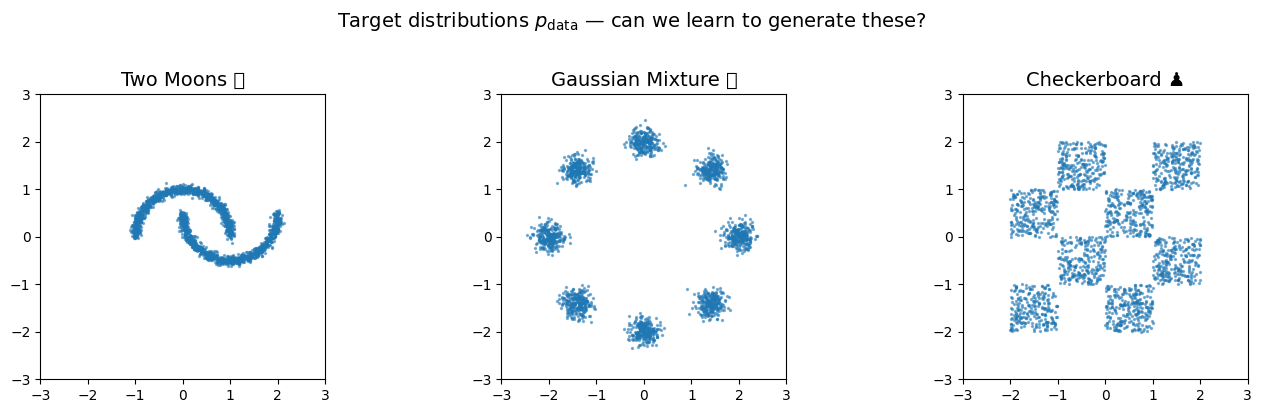

In [5]:
# Visualise the three target distributions
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, data) in zip(axes, {
    'Two Moons 🌙': sample_moons(2000),
    'Gaussian Mixture 💫': sample_gaussian_mixture(2000),
    'Checkerboard ♟️': sample_checkerboard(2000),
}.items()):
    ax.scatter(data[:, 0], data[:, 1], s=2, alpha=0.5)
    ax.set_title(name, fontsize=14)
    ax.set_aspect('equal'); ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
plt.suptitle(r'Target distributions $p_{\mathrm{data}}$ — can we learn to generate these?', y=1.02, fontsize=14)
plt.tight_layout(); plt.show()


The big idea behind flow matching (and diffusion models more broadly) is:

> **Start from a simple distribution we can sample from easily** (e.g., $\mathcal{N}(0, I)$) **and learn a transformation that turns it into the data distribution** $p_{\text{data}}$.

That "transformation" will be defined by an **ordinary differential equation** (ODE): a vector field that tells every point which direction to move. Let's see what that means. ↓


## 2. ODEs and Vector Fields ➡️

A **vector field** $u : \mathbb{R}^d \times [0, 1] \to \mathbb{R}^d$ assigns a velocity to every point in space, at every time. Given a starting point $x_0$, the ODE

$$\frac{d}{dt} X_t = u_t(X_t), \qquad X_0 = x_0$$

defines a trajectory $X_t$ that "follows" the vector field. The collection of all such trajectories, across all starting points, is called a **flow** $\psi_t$.

In practice we can't solve the ODE analytically — we use **numerical integration**. The simplest method is the **Euler method**:

$$X_{t+h} = X_t + h \cdot u_t(X_t), \qquad h = 1/n_{\text{steps}}$$

Before we build the Flow-Matching machinery, let's play with a simple *known* vector field and write our first numerical integrator.


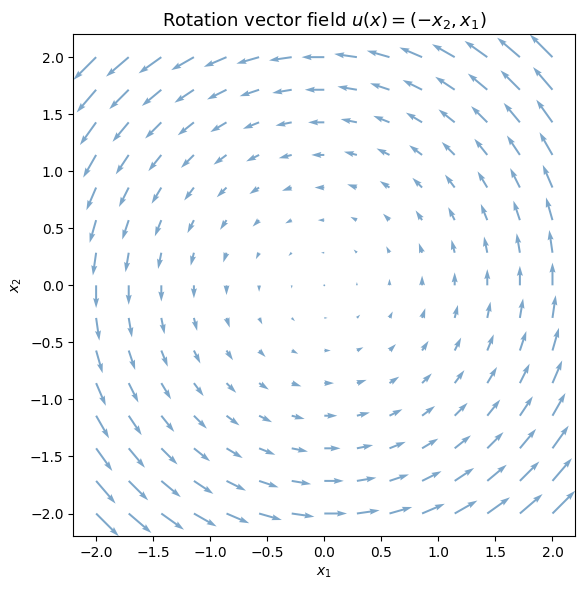

In [6]:
# A simple analytical vector field: rotation u(x) = (-x2, x1)
def rotation_field(x, t):
    return torch.stack([-x[:, 1], x[:, 0]], dim=1)

# Visualise the field
fig, ax = plt.subplots(figsize=(6, 6))
grid = torch.linspace(-2, 2, 15)
xx, yy = torch.meshgrid(grid, grid, indexing='ij')
points = torch.stack([xx.flatten(), yy.flatten()], dim=1)
velocities = rotation_field(points, t=0)
ax.quiver(points[:, 0], points[:, 1], velocities[:, 0], velocities[:, 1],
          color='steelblue', alpha=0.7)
ax.set_title('Rotation vector field $u(x) = (-x_2, x_1)$', fontsize=13)
ax.set_aspect('equal'); ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
plt.tight_layout(); plt.show()


### ✏️ Task 2.1 — Implement Euler integration

Write a function `euler_integrate(x0, v_fn, n_steps=100)` that integrates the ODE $\dot{x} = v(x, t)$ from $t=0$ to $t=1$ using the Euler method.

**Specification**

- **Inputs:**
  - `x0`: tensor of initial points, shape `(n_samples, d)`
  - `v_fn`: callable `v_fn(x, t)` returning velocities of shape `(n_samples, d)`
  - `n_steps`: number of Euler steps (so the step size is $h = 1/n_{\text{steps}}$)
- **Returns** a tuple `(x_final, trajectory)` where:
  - `x_final` is the tensor of points at $t=1$
  - `trajectory` is a list of `(x, t)` pairs — one entry per step, including the initial state — used later for nice visualisations

**💡 Hints**
- Step size: `h = 1.0 / n_steps`
- Each step: `x = x + h * v_fn(x, t)` then `t += h`
- Make sure `trajectory` has length `n_steps + 1`

**⚠️ Pitfalls**
- Don't forget to *also* append the starting state to the trajectory.
- `v_fn(x, t)` receives the *current* `x` and `t` — not the updated ones.


In [7]:
def euler_integrate(x0, v_fn, n_steps=100):
    # Integrate dx/dt = v_fn(x, t) from t=0 to t=1 using Euler's method.
    h = 1.0 / n_steps
    x = x0.clone()
    t = 0.0
    trajectory = [(x.clone(), t)]
    for _ in range(n_steps):
        x = x + h * v_fn(x, t)
        t += h
        trajectory.append((x.clone(), t))
    return x, trajectory


#### 🧪 Validate your implementation

Run the cell below. If every test passes you'll see a green ✅ summary.

In [8]:
test_euler_integrate(euler_integrate);


🧪 Testing euler_integrate


TEST SUMMARY — euler_integrate

✅ PASSED (6):
   • Return signature is (tensor, list)
   • Output shape matches input
   • Trajectory length = n_steps + 1
   • Exact integration of constant field
   • Euler approximates rotation ODE (fine discretisation)
   • Trajectory carries (x, t) pairs with t: 0 → 1

Total: 6/6 tests passed



🚀 **Time to play!** Let's integrate the rotation field and plot the resulting trajectories.

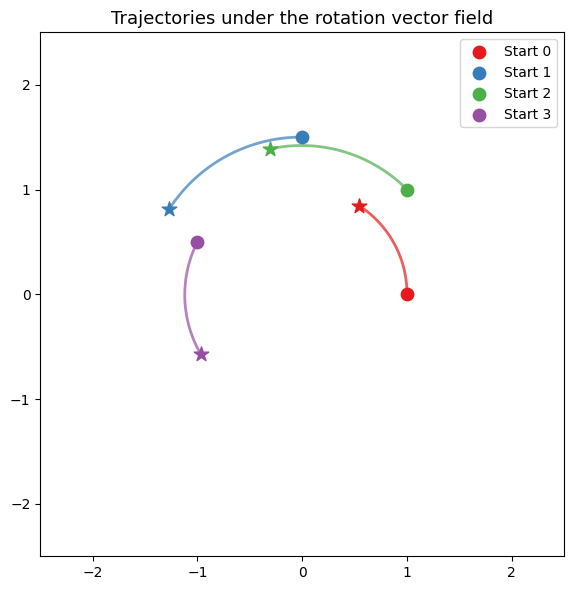

In [9]:
x0 = torch.tensor([[1.0, 0.0], [0.0, 1.5], [1.0, 1.0], [-1.0, 0.5]])
x1, traj = euler_integrate(x0, rotation_field, n_steps=100)

fig, ax = plt.subplots(figsize=(6, 6))
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']
for i in range(len(x0)):
    xs = [traj[s][0][i, 0].item() for s in range(len(traj))]
    ys = [traj[s][0][i, 1].item() for s in range(len(traj))]
    ax.plot(xs, ys, color=colors[i], alpha=0.7, lw=2)
    ax.scatter(xs[0],  ys[0],  color=colors[i], marker='o', s=80,  zorder=5, label=f'Start {i}')
    ax.scatter(xs[-1], ys[-1], color=colors[i], marker='*', s=120, zorder=5)

ax.set_title('Trajectories under the rotation vector field', fontsize=13)
ax.set_aspect('equal'); ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5); ax.legend()
plt.tight_layout(); plt.show()


The points rotate around the origin — exactly what we'd expect. 🎉

Now the key question: **if we could find the right vector field**, we could turn Gaussian noise into samples from *any* target distribution. How on earth do we find such a field? That's what Flow Matching is for. ⤵️


## 3. Conditional Probability Paths 🌉

The first trick of Flow Matching is to define a **probability path**: a smooth interpolation between a simple noise distribution $p_{\text{init}} = \mathcal{N}(0, I)$ at $t=0$ and the data distribution $p_{\text{data}}$ at $t=1$.

We cannot construct a path to the whole $p_{\text{data}}$ analytically — we don't know it! — but we **can** construct a path to a *single* data point $z$. We call this a **conditional probability path**:

$$p_t(\cdot \mid z): \qquad p_0(\cdot \mid z) = \mathcal{N}(0, I), \qquad p_1(\cdot \mid z) = \delta_z$$

The most common choice is the **Gaussian conditional path** with linear schedulers $\alpha_t = t$ and $\beta_t = 1 - t$:

$$p_t(x \mid z) = \mathcal{N}(\alpha_t z, \beta_t^2 I) = \mathcal{N}(t z,\, (1-t)^2 I)$$

We can sample from this by drawing noise $\epsilon \sim \mathcal{N}(0, I)$ and computing $x_t = t z + (1 - t) \epsilon$.

In the **I-CFM** formulation (our choice here), we work directly with pairs $(x_0, x_1)$ — $x_0$ is noise, $x_1$ is a data point — and linearly interpolate:

$$\boxed{\; x_t = (1 - t)\, x_0 + t\, x_1 \;}$$


### ✏️ Task 3.1 — Implement `sample_conditional_path`

Implement the linear interpolation $x_t = (1-t)\, x_0 + t\, x_1$.

**Specification**
- **Inputs:** `x0`, `x1` of shape `(batch, d)` and `t` of shape `(batch, 1)`
- **Returns:** `x_t` of shape `(batch, d)`

**💡 Hint** — thanks to broadcasting, the whole thing fits on one line.


In [10]:
def sample_conditional_path(x0, x1, t):
    # Linear conditional path: x_t = (1 - t) * x0 + t * x1
    return (1 - t) * x0 + t * x1


In [11]:
test_conditional_path(sample_conditional_path);


🧪 Testing sample_conditional_path


TEST SUMMARY — sample_conditional_path

✅ PASSED (4):
   • Output shape matches input
   • Endpoints: x_0 = x0 and x_1 = x1
   • Midpoint: x_{1/2} = (x0 + x1)/2
   • Per-sample time broadcasting

Total: 4/4 tests passed



🚀 Let's watch the path transport a batch of noise samples into the two-moons distribution.

/tmp/ipykernel_1242793/3642912104.py:12: UserWarning: Glyph 127744 (\N{CYCLONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1242793/3642912104.py:12: UserWarning: Glyph 127769 (\N{CRESCENT MOON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/home/users/fvaselli/.conda/envs/fad/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127744 (\N{CYCLONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


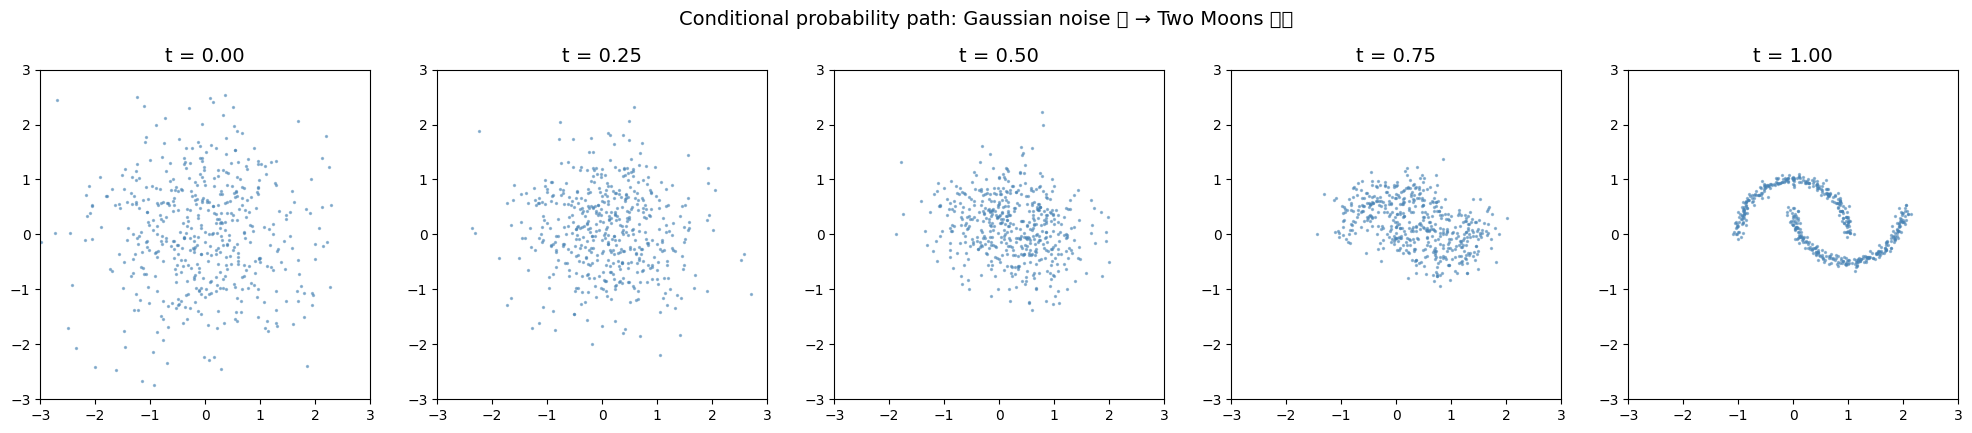

In [12]:
x1_data  = sample_moons(500)                 # target (t=1)
x0_noise = torch.randn_like(x1_data)         # source (t=0)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, t_val in zip(axes, [0.0, 0.25, 0.5, 0.75, 1.0]):
    t  = torch.full((len(x0_noise), 1), t_val)
    xt = sample_conditional_path(x0_noise, x1_data, t)
    ax.scatter(xt[:, 0], xt[:, 1], s=2, alpha=0.5, c='steelblue')
    ax.set_title(f't = {t_val:.2f}', fontsize=14)
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3); ax.set_aspect('equal')
plt.suptitle('Conditional probability path: Gaussian noise 🌀 → Two Moons 🌙🌙', y=1.02, fontsize=14)
plt.tight_layout(); plt.show()


### ✏️ Task 3.2 — Implement the conditional vector field

For our linear path, the velocity is particularly simple. Differentiating $x_t = (1-t) x_0 + t x_1$ in $t$:

$$u_t(x \mid x_1, x_0) = \frac{d x_t}{d t} = x_1 - x_0$$

It's literally the straight-line direction from the noise point to the data point. 📏

**Specification**
- **Inputs:** `x0`, `x1` of shape `(batch, d)`
- **Returns:** velocity of shape `(batch, d)`


In [13]:
def conditional_vector_field(x0, x1):
    # For the linear path, the velocity is x1 - x0.
    return x1 - x0


In [14]:
test_conditional_vector_field(conditional_vector_field);


🧪 Testing conditional_vector_field


TEST SUMMARY — conditional_vector_field

✅ PASSED (2):
   • Output shape matches input
   • Velocity equals x1 - x0

Total: 2/2 tests passed



🚀 Visualise the conditional vector field at $t = 0.5$.

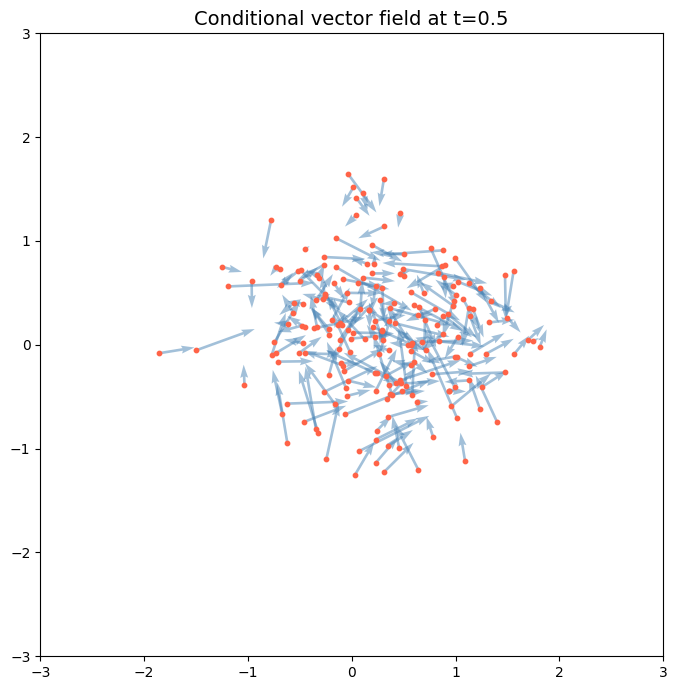

In [15]:
n_vis    = 200
x1_vis   = sample_moons(n_vis)
x0_vis   = torch.randn_like(x1_vis)
t_vis    = torch.full((n_vis, 1), 0.5)
x_t_vis  = sample_conditional_path(x0_vis, x1_vis, t_vis)
v_target = conditional_vector_field(x0_vis, x1_vis)

fig, ax = plt.subplots(figsize=(7, 7))
ax.quiver(x_t_vis[:, 0], x_t_vis[:, 1], v_target[:, 0], v_target[:, 1],
          alpha=0.5, color='steelblue', scale=30)
ax.scatter(x_t_vis[:, 0], x_t_vis[:, 1], s=10, c='tomato', zorder=5)
ax.set_title('Conditional vector field at t=0.5', fontsize=14)
ax.set_xlim(-3, 3); ax.set_ylim(-3, 3); ax.set_aspect('equal')
plt.tight_layout(); plt.show()


### 🔬 The marginalisation trick (why any of this works)

A key theoretical result (Theorem 9 in the lecture notes) is that the **marginal** vector field

$$u_t^{\text{target}}(x) = \int u_t^{\text{target}}(x \mid z)\, \frac{p_t(x \mid z)\, p_{\text{data}}(z)}{p_t(x)}\, dz$$

generates the marginal probability path $p_{\text{init}} \to p_{\text{data}}$.

We can't compute that integral. But we don't need to! The conditional flow-matching loss has the **same gradients** as the (intractable) marginal loss — so by regressing a neural network against the *conditional* velocity $u_t(x \mid z) = x_1 - x_0$ we **implicitly** learn the marginal vector field. 🤯

That's the content of the next section.


## 4. The Flow Matching Loss 📉

We train a neural network $u_\theta(x, t)$ to approximate the marginal vector field:

$$\mathcal{L}_{\text{FM}}(\theta) = \mathbb{E}_{t, x \sim p_t}\big[\lVert u_\theta(x, t) - u_t^{\text{target}}(x)\rVert^2\big]$$

The target is intractable. The magic (Theorem 12) is that the **conditional** flow-matching loss

$$\mathcal{L}_{\text{CFM}}(\theta) = \mathbb{E}_{t \sim \text{Unif}[0,1],\, z \sim p_{\text{data}},\, x \sim p_t(\cdot \mid z)}\big[\lVert u_\theta(x, t) - u_t^{\text{target}}(x \mid z)\rVert^2\big]$$

has **exactly the same gradients** as $\mathcal{L}_{\text{FM}}$. That's why regressing against the simple $x_1 - x_0$ is enough.

### 🥣 Training recipe

For each gradient step:

1. Sample a data point $x_1 \sim p_{\text{data}}$ and noise $x_0 \sim \mathcal{N}(0, I)$
2. Sample a random time $t \sim \text{Unif}[0, 1]$
3. Compute $x_t = (1-t)\, x_0 + t\, x_1$
4. Compute the target $u^{\text{target}} = x_1 - x_0$
5. Loss = $\lVert u_\theta(x_t, t) - (x_1 - x_0) \rVert^2$


### ✏️ Task 4.1 — Implement `flow_matching_loss`

Given a batch of real data `x1`, compute a one-step CFM loss following the recipe above.

**Specification**
- **Inputs:** `model` (a callable taking `x, t`), `x1` tensor of shape `(batch, d)`
- **Returns:** scalar loss tensor

**💡 Hints**
- `torch.randn_like(x1)` gives Gaussian noise with the right shape
- `torch.rand(batch, 1, device=x1.device)` samples uniform times
- `torch.mean((predicted - target) ** 2)` is the MSE

**⚠️ Pitfall** — Time `t` should be per-sample (shape `(batch, 1)`), not a scalar.


In [16]:
def flow_matching_loss(model, x1):
    # Conditional Flow Matching loss.
    batch_size = x1.shape[0]
    x0 = torch.randn_like(x1)
    t = torch.rand(batch_size, 1, device=x1.device)
    x_t = (1 - t) * x0 + t * x1
    target = x1 - x0
    predicted = model(x_t, t)
    return torch.mean((predicted - target) ** 2)


## 5. The Neural Network 🧠

We now need a neural network that takes $(x_t, t)$ as input and outputs the velocity $u_\theta(x_t, t)$.

The network has to:
- accept a **batch of points** `x` of shape `(B, d)`
- accept a **time** `t` (scalar or per-sample, `(B, 1)`)
- output a velocity of shape `(B, d)`

The simplest recipe — and the one we'll use — is to **concatenate `t` as an extra input feature** and run a standard MLP on `(x, t)`:

```
x  ────┐
        ├── concat ──► Linear ──► SiLU ──► ... ──► Linear ──► velocity
t  ────┘              (d+1)                          (d)
```

### ✏️ Task 5.1 — Implement `SimpleVectorField`

Build a small MLP class with configurable depth and width.

**Specification**
- `__init__(self, d=2, hidden_dim=128, n_layers=3)`:
  - input dim is `d + 1` (spatial + time)
  - `n_layers` hidden linear layers of width `hidden_dim` each, with **SiLU** activations
  - a final linear layer maps to `d` (the output velocity has the same dim as `x`)
- `forward(self, x, t)`:
  - must handle `t` as a **scalar**, a **(B,)** tensor, or a **(B, 1)** tensor — reshape to `(B, 1)` before concatenation
  - concatenate `x` and `t` along the last dim, then pass through the MLP

**💡 Hints**
- Use `nn.Sequential` of `nn.Linear` + `nn.SiLU` + ... + `nn.Linear`
- Check `t.dim()` to decide how to reshape
- Broadcast a scalar `t` to shape `(B, 1)` with `torch.full((B, 1), t.item())` — or `t.expand(B, 1)` after `unsqueeze`

**⚠️ Pitfall** — If your network ignores `t` (e.g., you forgot to concat it), the loss will stall at a plateau because the field can't depend on time. The test will catch this.

**🎁 Bonus (optional)** — Instead of concatenating the raw scalar `t`, use a **sinusoidal time embedding** $\tau(t) = [\sin(\omega_i t), \cos(\omega_i t)]_i$ with logarithmically-spaced frequencies $\omega_i$. This gives the network many different "phases" of the time signal and usually trains noticeably better. Try it after the basic version works. 🎶


In [17]:
class SimpleVectorField(nn.Module):
    # MLP that maps (x, t) -> velocity.
    def __init__(self, d=2, hidden_dim=128, n_layers=3):
        super().__init__()
        layers = [nn.Linear(d + 1, hidden_dim), nn.SiLU()]
        for _ in range(n_layers - 1):
            layers.extend([nn.Linear(hidden_dim, hidden_dim), nn.SiLU()])
        layers.append(nn.Linear(hidden_dim, d))
        self.net = nn.Sequential(*layers)

    def forward(self, x, t):
        # Accept t as scalar, (batch,), or (batch, 1)
        if t.dim() == 0:
            t = t.unsqueeze(0).expand(x.shape[0], 1)
        elif t.dim() == 1:
            t = t.unsqueeze(1)
        return self.net(torch.cat([x, t], dim=1))


#### 🧪 Validate your network

In [18]:
test_simple_vector_field(SimpleVectorField);


🧪 Testing SimpleVectorField


TEST SUMMARY — SimpleVectorField

✅ PASSED (7):
   • Constructs as an nn.Module with parameters
   • Forward pass returns correct shape and finite values
   • Handles t as scalar, (B,), and (B, 1)
   • Different inputs produce different outputs
   • Output depends on t
   • Gradients flow through every parameter
   • Parameter count scales with width/depth (370 → 12866)

Total: 7/7 tests passed



Now that we have both a `flow_matching_loss` and a `SimpleVectorField`, let's re-run the loss test with the real network — this additionally checks that gradients flow end-to-end.

In [19]:
test_flow_matching_loss(flow_matching_loss, model_cls=SimpleVectorField);


🧪 Testing flow_matching_loss


TEST SUMMARY — flow_matching_loss

✅ PASSED (3):
   • Loss is a finite, non-negative scalar
   • Loss produces non-zero gradients for the model
   • Oracle predictor achieves zero loss

Total: 3/3 tests passed



## 5b. Training and Sampling 🏋️

### ✏️ Task 5.2 — Implement the training loop

Write a function `train_flow_model(model, sample_fn, n_epochs=2000, batch_size=512, lr=1e-3)` that trains `model` using the CFM loss and returns the per-epoch loss list.

**💡 Hints**
- Use `torch.optim.Adam`
- Standard PyTorch dance: `optimizer.zero_grad()` → `loss.backward()` → `optimizer.step()`
- Log the loss every 500 epochs so you know it's making progress
- Make sure the batch from `sample_fn(batch_size)` is moved to the model's `device`


In [20]:
def train_flow_model(model, sample_fn, n_epochs=2000, batch_size=512, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    losses = []
    model_device = next(model.parameters()).device
    for epoch in range(n_epochs):
        x1 = sample_fn(batch_size).to(model_device)
        loss = flow_matching_loss(model, x1)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        if (epoch + 1) % 500 == 0:
            print(f'Epoch {epoch+1}/{n_epochs}  Loss: {loss.item():.4f}')
    return losses


In [21]:
test_train_flow_model(train_flow_model, model_cls=SimpleVectorField);


🧪 Testing train_flow_model (quick 200-epoch run)




TEST SUMMARY — train_flow_model

✅ PASSED (2):
   • Training runs and returns 200 losses
   • Training reduces loss (2.562 → 0.325)

Total: 2/2 tests passed



### ✏️ Task 5.3 — Implement `generate_samples`

To generate samples from the trained model:
1. Start with $x_0 \sim \mathcal{N}(0, I)$
2. Integrate the ODE $\dot{x} = u_\theta(x, t)$ from $t=0$ to $t=1$ using your Euler integrator
3. Return the final $x_1$

**💡 Hint** — The adapter between your integrator and the network is a small closure:

```python
def v_fn(x, t):
    t_tensor = torch.full((x.shape[0], 1), t, device=device)
    return model(x, t_tensor)
```

Reuse your `euler_integrate`! ♻️


In [22]:
@torch.no_grad()
def generate_samples(model, n_samples, n_steps=100, d=2):
    device = next(model.parameters()).device
    x0 = torch.randn(n_samples, d, device=device)

    def v_fn(x, t):
        t_tensor = torch.full((x.shape[0], 1), t, device=device)
        return model(x, t_tensor)

    samples, _ = euler_integrate(x0, v_fn, n_steps=n_steps)
    return samples


In [23]:
test_generate_samples(generate_samples, model_cls=SimpleVectorField);


🧪 Testing generate_samples


TEST SUMMARY — generate_samples

✅ PASSED (2):
   • Output shape is (n_samples, d) and finite
   • Sampling is stochastic across calls

Total: 2/2 tests passed



### 🚀 Train on Two Moons

In [24]:
model_moons   = SimpleVectorField(d=2, hidden_dim=128, n_layers=5).to(device)
losses_moons  = train_flow_model(model_moons, sample_moons, n_epochs=5000, batch_size=1024)


Epoch 500/5000  Loss: 0.9975
Epoch 1000/5000  Loss: 0.9835
Epoch 1500/5000  Loss: 0.9488
Epoch 2000/5000  Loss: 0.9308
Epoch 2500/5000  Loss: 0.9391
Epoch 3000/5000  Loss: 0.9598
Epoch 3500/5000  Loss: 0.9207
Epoch 4000/5000  Loss: 0.9587
Epoch 4500/5000  Loss: 0.9681
Epoch 5000/5000  Loss: 0.9359


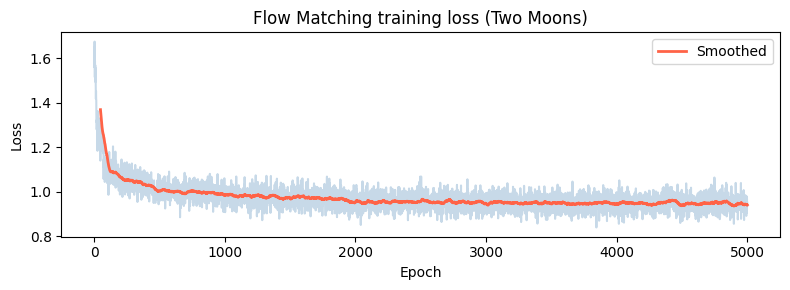

In [25]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(losses_moons, alpha=0.3, color='steelblue')
window   = 50
smoothed = np.convolve(losses_moons, np.ones(window) / window, mode='valid')
ax.plot(range(window - 1, len(losses_moons)), smoothed, color='tomato', lw=2, label='Smoothed')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Flow Matching training loss (Two Moons)')
ax.legend(); plt.tight_layout(); plt.show()


/tmp/ipykernel_1242793/3484560110.py:11: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1242793/3484560110.py:11: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/home/users/fvaselli/.conda/envs/fad/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/users/fvaselli/.conda/envs/fad/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


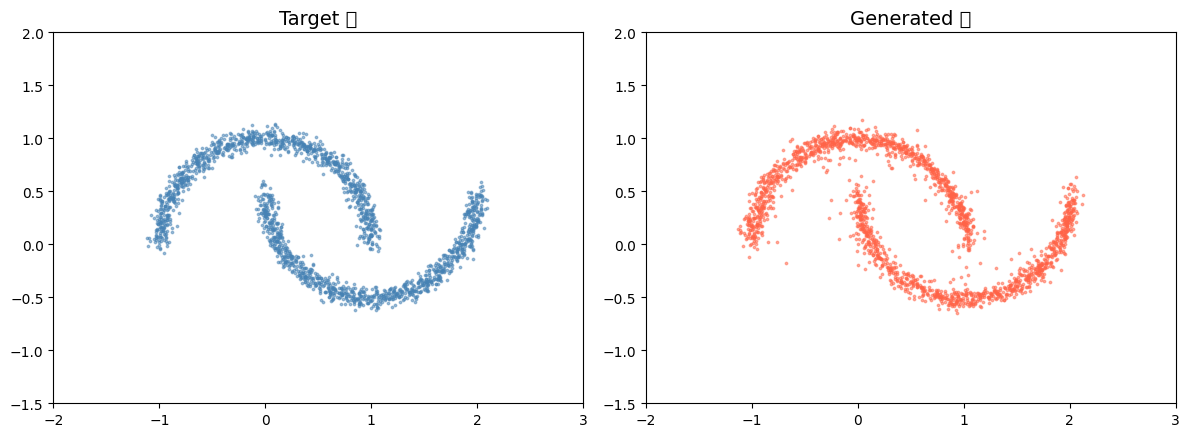

In [26]:
generated = generate_samples(model_moons, n_samples=2000, n_steps=100).cpu()
target    = sample_moons(2000)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(target[:, 0],    target[:, 1],    s=3, alpha=0.5, c='steelblue')
axes[0].set_title('Target 🎯', fontsize=14)
axes[1].scatter(generated[:, 0], generated[:, 1], s=3, alpha=0.5, c='tomato')
axes[1].set_title('Generated ✨', fontsize=14)
for ax in axes:
    ax.set_xlim(-2, 3); ax.set_ylim(-1.5, 2); ax.set_aspect('equal')
plt.tight_layout(); plt.show()


#### Watch the flow in action 🎞️

/tmp/ipykernel_1242793/566239621.py:17: UserWarning: Glyph 127744 (\N{CYCLONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1242793/566239621.py:17: UserWarning: Glyph 127769 (\N{CRESCENT MOON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/home/users/fvaselli/.conda/envs/fad/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127744 (\N{CYCLONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/users/fvaselli/.conda/envs/fad/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127769 (\N{CRESCENT MOON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


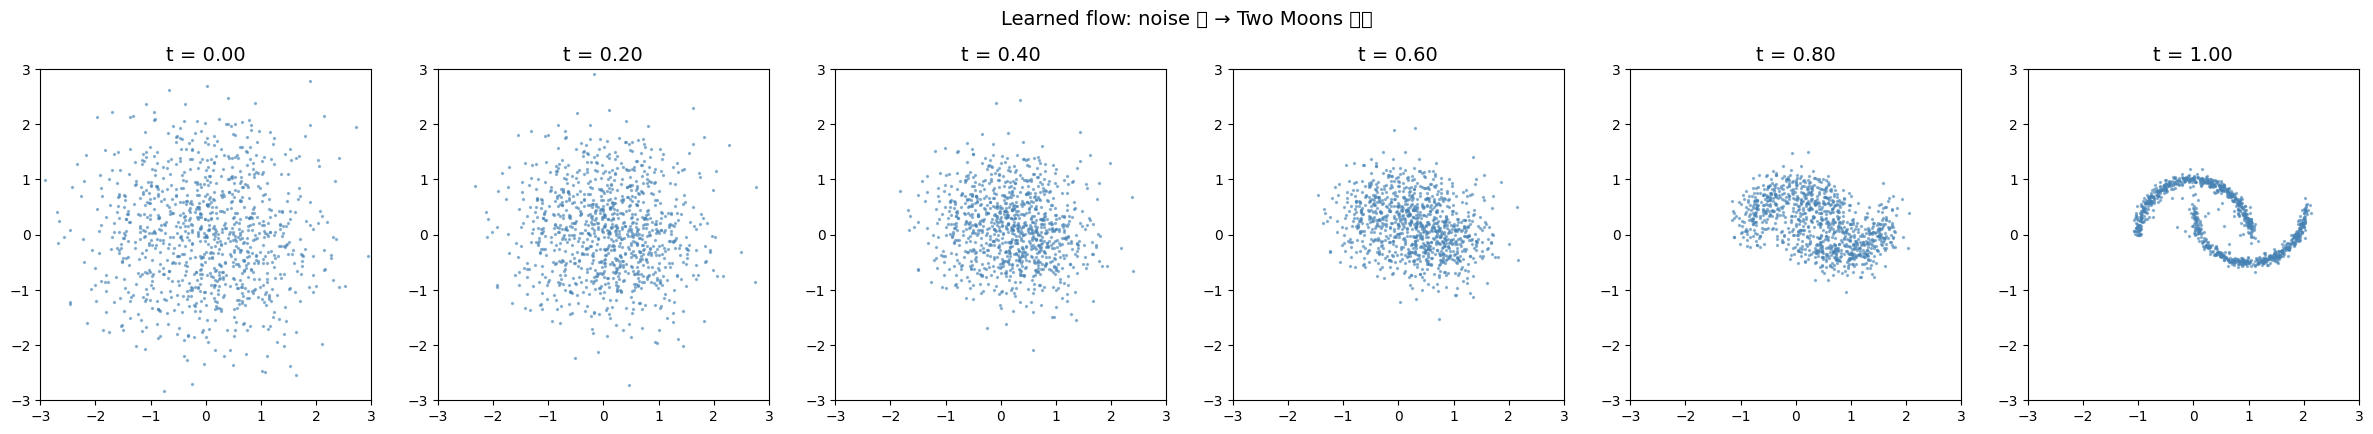

In [27]:
n_vis   = 1000
x0_vis  = torch.randn(n_vis, 2, device=device)

def model_v_fn(x, t):
    t_tensor = torch.full((x.shape[0], 1), t, device=device)
    return model_moons(x, t_tensor)

_, trajectory = euler_integrate(x0_vis, model_v_fn, n_steps=100)

fig, axes = plt.subplots(1, 6, figsize=(24, 4))
for ax, idx in zip(axes, [0, 20, 40, 60, 80, 100]):
    points = trajectory[idx][0].detach().cpu(); t_val = trajectory[idx][1]
    ax.scatter(points[:, 0], points[:, 1], s=2, alpha=0.5, c='steelblue')
    ax.set_title(f't = {t_val:.2f}', fontsize=14)
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3); ax.set_aspect('equal')
plt.suptitle('Learned flow: noise 🌀 → Two Moons 🌙🌙', y=1.02, fontsize=14)
plt.tight_layout(); plt.show()


### 🧑‍🔬 Try other distributions

Let's push our code on the Gaussian mixture and checkerboard targets. The checkerboard is the hardest (disconnected support!) and benefits from a deeper network and more epochs.

In [28]:
model_gmm  = SimpleVectorField(d=2, hidden_dim=128, n_layers=5).to(device)
losses_gmm = train_flow_model(model_gmm, sample_gaussian_mixture, n_epochs=5000, batch_size=1024)


Epoch 500/5000  Loss: 1.8306
Epoch 1000/5000  Loss: 1.9487
Epoch 1500/5000  Loss: 1.9148
Epoch 2000/5000  Loss: 1.9080
Epoch 2500/5000  Loss: 1.9562
Epoch 3000/5000  Loss: 1.9915
Epoch 3500/5000  Loss: 1.9918
Epoch 4000/5000  Loss: 1.8335
Epoch 4500/5000  Loss: 1.8100
Epoch 5000/5000  Loss: 2.0072


In [29]:
model_cb   = SimpleVectorField(d=2, hidden_dim=128, n_layers=5).to(device)
losses_cb  = train_flow_model(model_cb, sample_checkerboard, n_epochs=5000, batch_size=1024)


Epoch 500/5000  Loss: 1.8105
Epoch 1000/5000  Loss: 1.8434
Epoch 1500/5000  Loss: 1.6861
Epoch 2000/5000  Loss: 1.7607
Epoch 2500/5000  Loss: 1.6882
Epoch 3000/5000  Loss: 1.7209
Epoch 3500/5000  Loss: 1.6878
Epoch 4000/5000  Loss: 1.7058
Epoch 4500/5000  Loss: 1.5931
Epoch 5000/5000  Loss: 1.6555


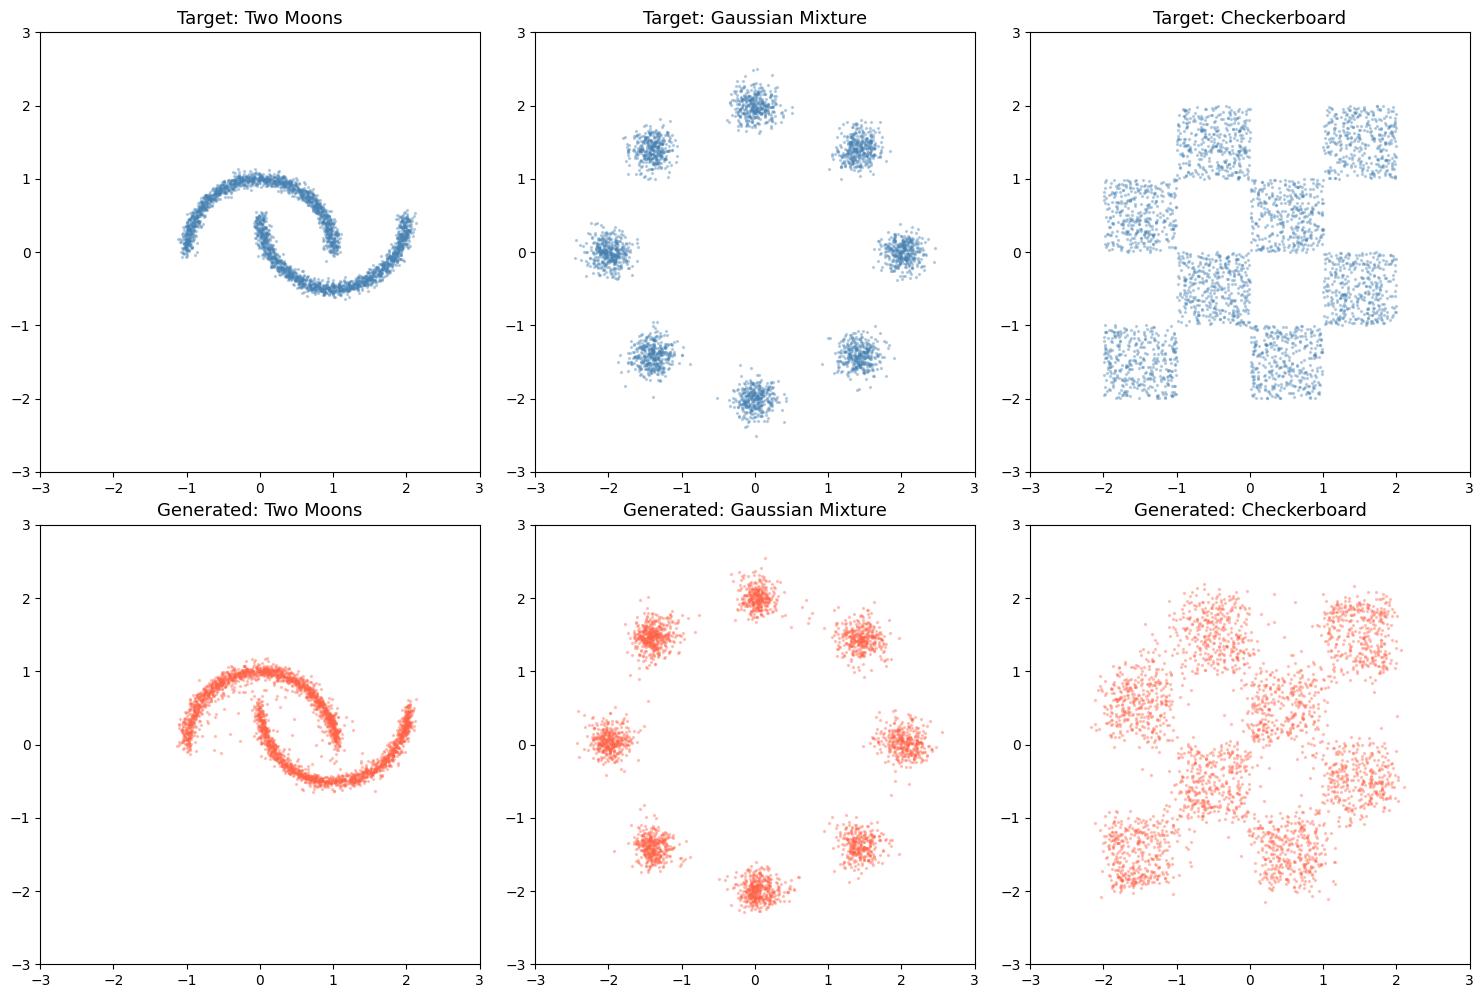

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for j, (name, sample_fn, model) in enumerate([
    ('Two Moons',         sample_moons,             model_moons),
    ('Gaussian Mixture',  sample_gaussian_mixture,  model_gmm),
    ('Checkerboard',      sample_checkerboard,      model_cb),
]):
    target    = sample_fn(3000)
    generated = generate_samples(model, 3000, n_steps=100).cpu()
    axes[0, j].scatter(target[:, 0],    target[:, 1],    s=2, alpha=0.3, c='steelblue')
    axes[0, j].set_title(f'Target: {name}', fontsize=13)
    axes[1, j].scatter(generated[:, 0], generated[:, 1], s=2, alpha=0.3, c='tomato')
    axes[1, j].set_title(f'Generated: {name}', fontsize=13)
    for ax in axes[:, j]:
        ax.set_xlim(-3, 3); ax.set_ylim(-3, 3); ax.set_aspect('equal')
plt.tight_layout(); plt.show()


## 6. Better Integrators — Heun's Method 🏃‍♀️

Euler's method has **local truncation error** $\mathcal{O}(h^2)$, so the global error after $N$ steps is $\mathcal{O}(h) = \mathcal{O}(1/N)$. That's why we needed 100+ steps for a decent picture.

**Heun's method** (a second-order Runge–Kutta) improves this to $\mathcal{O}(h^3)$ local / $\mathcal{O}(h^2)$ global — at the cost of **two** vector-field evaluations per step instead of one. For the same budget of network calls, it's usually a big win:

$$\begin{aligned}
k_1 &= u_t(X_t,\, t) \\
k_2 &= u_t(X_t + h\,k_1,\; t + h) \\
X_{t+h} &= X_t + \tfrac{h}{2}\,(k_1 + k_2)
\end{aligned}$$

Think of it as "take an Euler step to get a trial point, evaluate the field there, then average the two slopes." 🧭

### ✏️ Task 6.1 — Implement `heun_integrate`

Same signature and return type as `euler_integrate`.

**💡 Hint** — You can copy-paste your Euler code and only change the update step. Both return `(x_final, trajectory)`.

**⚠️ Pitfall** — The trial point `X_t + h*k_1` is a *probe* — don't mutate `x` with it. Only `X_t + (h/2)(k_1 + k_2)` should go into `x`.


In [31]:
def heun_integrate(x0, v_fn, n_steps=100):
    # Integrate dx/dt = v_fn(x, t) from t=0 to t=1 using Heun's (RK2) method.
    h = 1.0 / n_steps
    x = x0.clone()
    t = 0.0
    trajectory = [(x.clone(), t)]
    for _ in range(n_steps):
        k1 = v_fn(x, t)
        k2 = v_fn(x + h * k1, t + h)
        x = x + 0.5 * h * (k1 + k2)
        t += h
        trajectory.append((x.clone(), t))
    return x, trajectory


In [32]:
test_heun_integrate(heun_integrate);


🧪 Testing heun_integrate


TEST SUMMARY — heun_integrate

✅ PASSED (5):
   • Return signature is (tensor, list)
   • Shape preserved and trajectory length = n_steps + 1
   • Exact on constant vector field
   • More accurate than Euler at n_steps=20 (Heun 3.42e-04 < Euler 2.08e-02)
   • Converges to analytic rotation solution (err=1.07e-06)

Total: 5/5 tests passed



### 🔬 Euler vs. Heun — side by side

Let's compare sample quality from the trained moons model using a small number of integration steps. Remember: each **Heun step** costs *two* model evaluations, so the fair comparison is "Heun with $N/2$ steps vs. Euler with $N$ steps" — same compute budget.

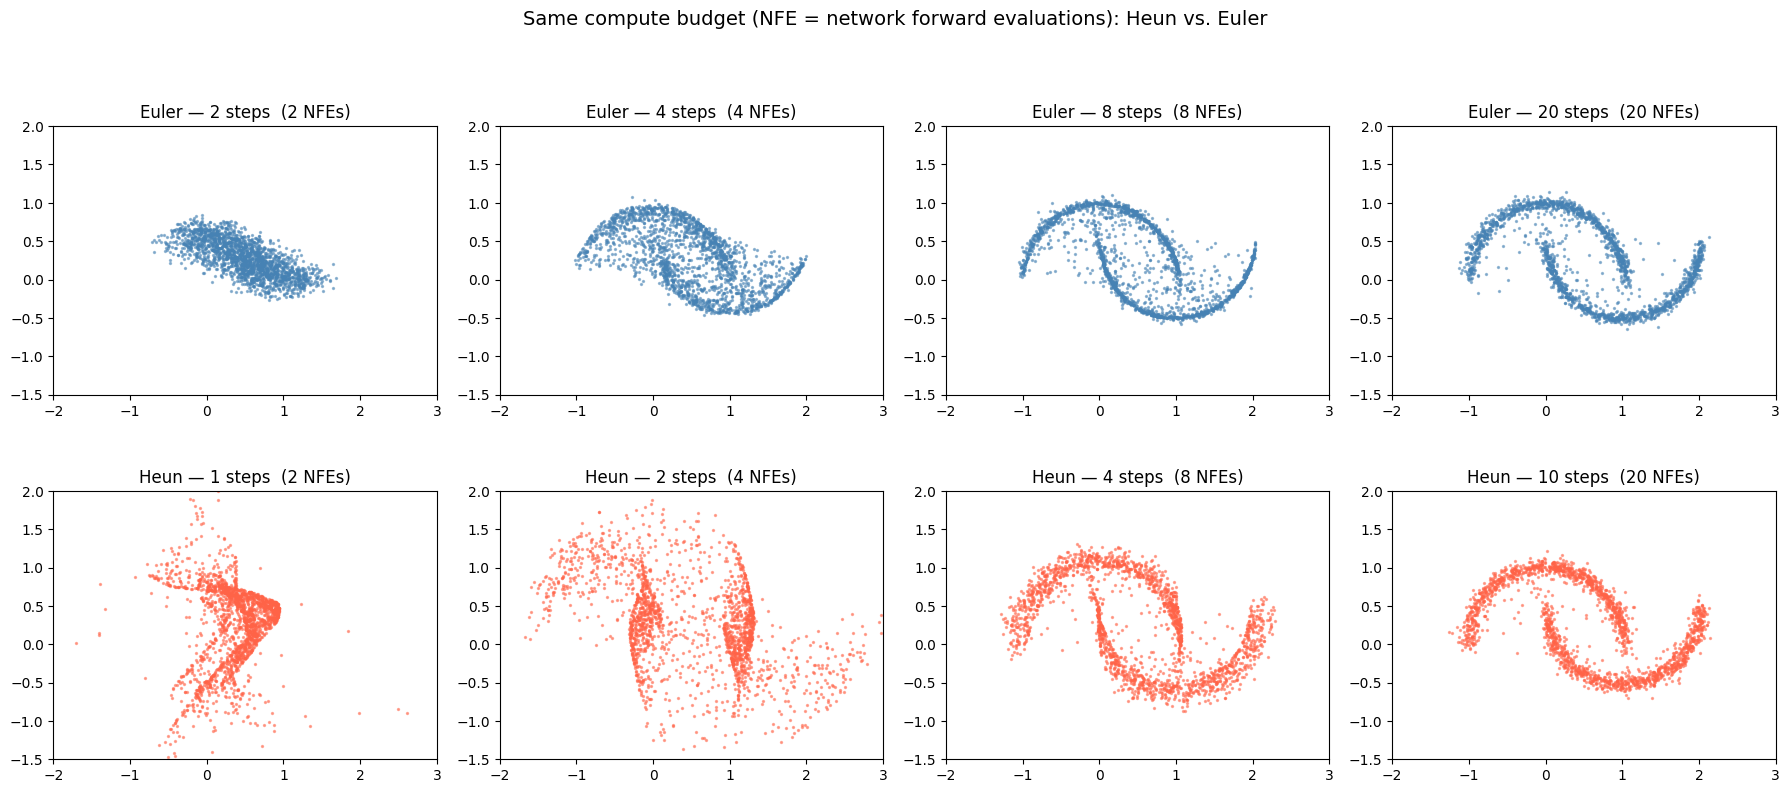

In [33]:
@torch.no_grad()
def generate_with(model, integrator, n_samples=2000, n_steps=100, d=2):
    device = next(model.parameters()).device
    x0 = torch.randn(n_samples, d, device=device)
    def v_fn(x, t):
        return model(x, torch.full((x.shape[0], 1), t, device=device))
    samples, _ = integrator(x0, v_fn, n_steps=n_steps)
    return samples.cpu()

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
step_counts = [2, 4, 8, 20]
for j, n in enumerate(step_counts):
    axes[0, j].scatter(*generate_with(model_moons, euler_integrate, n_steps=n).T, s=2, alpha=0.5, c='steelblue')
    axes[0, j].set_title(f'Euler — {n} steps  ({n} NFEs)', fontsize=12)
    axes[1, j].scatter(*generate_with(model_moons, heun_integrate, n_steps=n // 2 or 1).T, s=2, alpha=0.5, c='tomato')
    axes[1, j].set_title(f'Heun — {n // 2 or 1} steps  ({n} NFEs)', fontsize=12)
    for r in range(2):
        axes[r, j].set_xlim(-2, 3); axes[r, j].set_ylim(-1.5, 2); axes[r, j].set_aspect('equal')
plt.suptitle('Same compute budget (NFE = network forward evaluations): Heun vs. Euler', y=1.02, fontsize=14)
plt.tight_layout(); plt.show()


Observation: at very low NFE (≤ 8) Heun typically produces qualitatively nicer samples than Euler, at the same cost. 💸

In practice, production flow-matching models use **Dormand–Prince** (RK4(5)) with adaptive step sizes — but Heun is already a solid upgrade over Euler in a handful of lines.

## 7. Invertibility — Run the Flow Backwards ⏪

A beautiful consequence of the Flow-Matching setup is that the learned ODE is a **diffeomorphism**: it's smooth, invertible, and the inverse has the same cost as the forward pass.

To invert, we integrate

$$\frac{d X_t}{d t} = u_\theta(X_t, t)$$

**backwards in time** from $t=1$ down to $t=0$. Equivalently, we change variables with $s = 1 - t$ and integrate the field $-u_\theta(x, 1-s)$ forward in $s$ from $0$ to $1$. No new integrator needed — we just wrap the model.

If the model has learned well, feeding **data** into the backward pass should give samples that look like **pure Gaussian noise**. Let's check. 🔎


In [34]:
@torch.no_grad()
def encode_samples(model, x1, n_steps=100):
    # Integrate the reversed ODE: s in [0, 1] corresponds to t = 1 - s.
    device = next(model.parameters()).device
    x1 = x1.to(device)

    def v_rev(x, s):
        t = 1.0 - s
        t_tensor = torch.full((x.shape[0], 1), t, device=device)
        return -model(x, t_tensor)

    noise, _ = euler_integrate(x1, v_rev, n_steps=n_steps)
    return noise


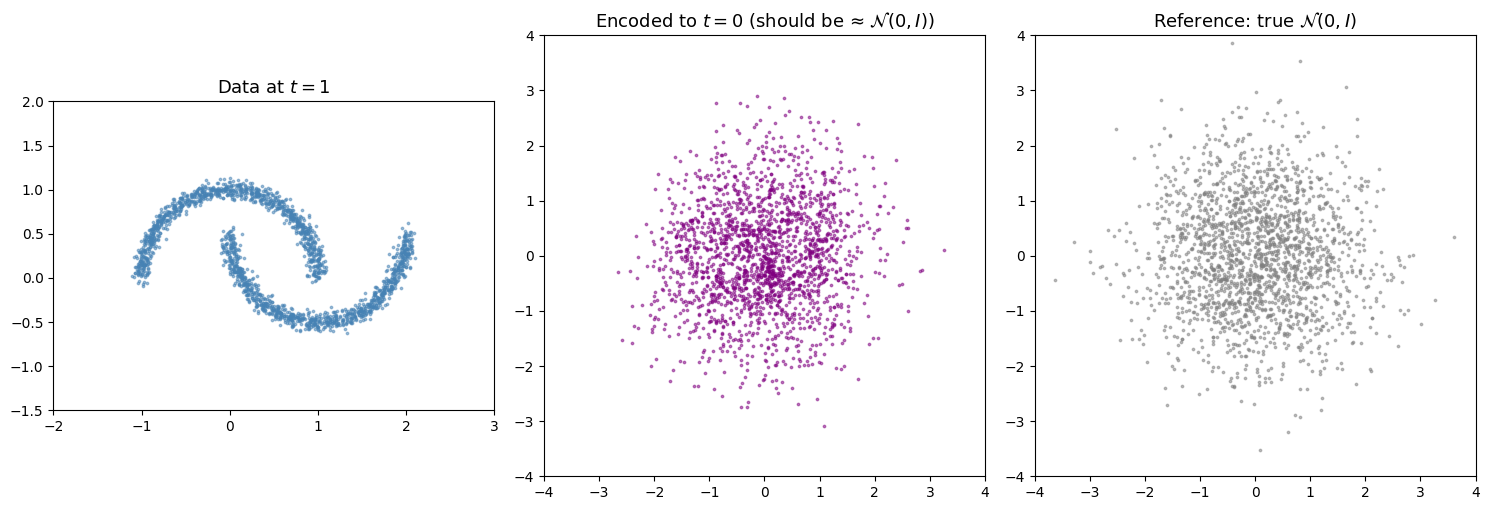

Encoded mean: [-0.03595981 -0.00617649]  (expected ~[0, 0])
Encoded std:  [0.9271888  0.95509976]  (expected ~[1, 1])


In [35]:
# Run our trained moons model backwards on real data
real_moons  = sample_moons(2000).to(device)
encoded     = encode_samples(model_moons, real_moons, n_steps=100).cpu()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].scatter(real_moons.cpu()[:, 0], real_moons.cpu()[:, 1], s=3, alpha=0.5, c='steelblue')
axes[0].set_title('Data at $t=1$', fontsize=13)
axes[0].set_xlim(-2, 3); axes[0].set_ylim(-1.5, 2); axes[0].set_aspect('equal')

axes[1].scatter(encoded[:, 0], encoded[:, 1], s=3, alpha=0.5, c='purple')
axes[1].set_title('Encoded to $t=0$ (should be ≈ $\\mathcal{N}(0, I)$)', fontsize=13)
axes[1].set_xlim(-4, 4); axes[1].set_ylim(-4, 4); axes[1].set_aspect('equal')

# Compare against actual Gaussian noise for reference
ref_noise = torch.randn(2000, 2)
axes[2].scatter(ref_noise[:, 0], ref_noise[:, 1], s=3, alpha=0.5, c='gray')
axes[2].set_title('Reference: true $\\mathcal{N}(0, I)$', fontsize=13)
axes[2].set_xlim(-4, 4); axes[2].set_ylim(-4, 4); axes[2].set_aspect('equal')
plt.tight_layout(); plt.show()

# Quick sanity check: encoded samples should have mean ~0 and std ~1
print(f'Encoded mean: {encoded.mean(dim=0).numpy()}  (expected ~[0, 0])')
print(f'Encoded std:  {encoded.std(dim=0).numpy()}  (expected ~[1, 1])')


Neat! 🎉 A single network simultaneously learns **how to generate** (noise → data) and **how to encode** (data → noise), for free. This property is one of the reasons flow matching is such an appealing framework.

## 8. Bonus — Effect of Integration Steps 🔍

A last look at the accuracy–speed trade-off. The number of integration steps controls how faithfully we solve the ODE. Let's sweep it for Euler on the moons model.

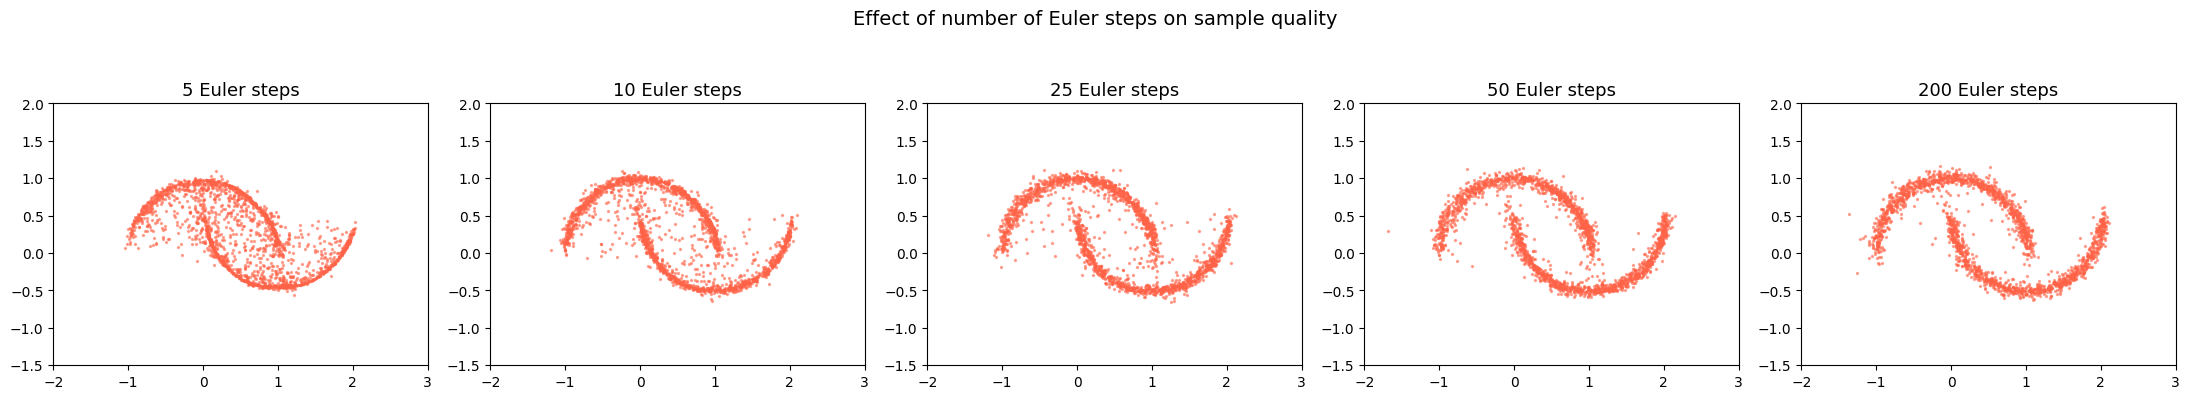

In [36]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, n_steps in zip(axes, [5, 10, 25, 50, 200]):
    generated = generate_samples(model_moons, 2000, n_steps=n_steps).cpu()
    ax.scatter(generated[:, 0], generated[:, 1], s=2, alpha=0.5, c='tomato')
    ax.set_title(f'{n_steps} Euler steps', fontsize=13)
    ax.set_xlim(-2, 3); ax.set_ylim(-1.5, 2); ax.set_aspect('equal')
plt.suptitle('Effect of number of Euler steps on sample quality', y=1.02, fontsize=14)
plt.tight_layout(); plt.show()


Very few steps produce poor samples (the ODE is integrated crudely), while too many are wasteful. In practice 50–200 Euler steps (or ~25 Heun steps — same NFE!) is a good range.

## 9. Final Comprehensive Test ✅

Run the full test suite one more time to confirm everything is in order before moving on to Notebook 2.

In [37]:
run_all_tests(
    euler_integrate=euler_integrate,
    sample_conditional_path=sample_conditional_path,
    conditional_vector_field=conditional_vector_field,
    flow_matching_loss=flow_matching_loss,
    generate_samples=generate_samples,
    train_flow_model=train_flow_model,
    model_cls=SimpleVectorField,
    heun_integrate=heun_integrate,
);



🚀 RUNNING COMPREHENSIVE TEST SUITE — Notebook 1

🧪 Testing euler_integrate


TEST SUMMARY — euler_integrate

✅ PASSED (6):
   • Return signature is (tensor, list)
   • Output shape matches input
   • Trajectory length = n_steps + 1
   • Exact integration of constant field
   • Euler approximates rotation ODE (fine discretisation)
   • Trajectory carries (x, t) pairs with t: 0 → 1

Total: 6/6 tests passed

🧪 Testing sample_conditional_path


TEST SUMMARY — sample_conditional_path

✅ PASSED (4):
   • Output shape matches input
   • Endpoints: x_0 = x0 and x_1 = x1
   • Midpoint: x_{1/2} = (x0 + x1)/2
   • Per-sample time broadcasting

Total: 4/4 tests passed

🧪 Testing conditional_vector_field


TEST SUMMARY — conditional_vector_field

✅ PASSED (2):
   • Output shape matches input
   • Velocity equals x1 - x0

Total: 2/2 tests passed

🧪 Testing flow_matching_loss


TEST SUMMARY — flow_matching_loss

✅ PASSED (3):
   • Loss is a finite, non-negative scalar
   • Loss produces non-zero gra

## 🏁 Summary

In this notebook you:

1. Met **generative modelling** as the problem of sampling from an unknown distribution.
2. Wrote a tiny **Euler ODE integrator** and used it to follow a rotation vector field.
3. Built a **conditional probability path** — the straight line $x_t = (1 - t) x_0 + t x_1$ — and saw that its velocity is just $x_1 - x_0$.
4. Implemented the **Conditional Flow Matching loss** — the one loss that lets a neural network learn the marginal vector field even though the marginal is intractable.
5. Built the **neural vector field** yourself and trained it on three different 2D distributions.
6. Upgraded to **Heun's (RK2) integrator** and saw it beat Euler at the same compute budget.
7. Ran the flow **backwards** and confirmed that the learned ODE is a diffeomorphism — data encodes back to ≈ Gaussian noise.

### ➡️ Next up

In **Notebook 2** we'll apply exactly these ideas to a real physics problem: simulating reconstruction-level jet features at the CMS experiment with a conditional flow-matching network. 🥽

### 📎 Further reading

- Morning Seminar on Flow Matching
- [MIT Class on Generative models from ODEs](https://diffusion.csail.mit.edu/2026/index.html)
- [Camridge MLG intro to Flow Matching](https://mlg.eng.cam.ac.uk/blog/2024/01/20/flow-matching.html)
